In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import netCDF4 as nc
from scipy.stats import linregress
from scipy.spatial import cKDTree

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import phys_grad, compute_core_mean, add_region_column


In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


In [4]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tilt_vert_checked.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_eddies = add_region_column(
    df_eddies,
    X_grid, Y_grid,
    lon_rho, lat_rho,
    h, mask_rho
)
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,118.032741,47.992205,1.434563,74.597458,38,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,U2
1,1,1463,CE,160.982386,-29.745743,260,274,920.121471,1352.093925,-0.000014,...,115.905401,50.858737,1.417135,76.449111,38,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,U2
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,113.778061,53.725269,1.413542,78.300764,38,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,U2
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,111.650721,56.591801,1.411879,69.625773,38,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,33.976810,184.917206,U2
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,115.925719,57.471319,1.597888,72.613632,38,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.067059,181.174121,U2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125221,2929,10646,CE,153.739453,-37.488262,181,61,515.983450,302.961328,-0.000026,...,61.312206,19.408106,1.110214,55.409919,28,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,0.752304,4.278123,D1
125222,2929,10647,CE,153.687115,-37.523299,181,60,512.684226,297.695084,-0.000027,...,61.305207,19.388829,1.037331,44.896186,28,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,1.165623,28.370419,D1
125223,2929,10648,CE,153.699708,-37.537452,181,60,514.199660,296.590511,-0.000021,...,61.298208,19.369553,1.055789,38.796956,28,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
125224,2929,10649,CE,153.682657,-37.451789,180,62,510.019363,305.068558,-0.000019,...,64.546558,19.604126,1.070344,40.028670,28,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1


## Potential-vorticity gradient including eddy vorticity

Starting from the barotropic potential vorticity,

$$
PV = \frac{\omega + f}{h},
$$

where $\omega$ is the relative vorticity, $f$ is the Coriolis parameter, and $h$ is the local water depth.

Rather than neglecting relative vorticity entirely, we assume that its horizontal gradients are small compared with the planetary and bathymetric contributions,

$$
\frac{\partial \omega}{\partial x} \approx 0,
\qquad
\frac{\partial \omega}{\partial y} \approx 0.
$$

Under this approximation,

$$
\frac{\partial PV}{\partial x}
=
-\frac{\omega+f}{h^2}\frac{\partial h}{\partial x},
$$

and

$$
\frac{\partial PV}{\partial y}
=
\frac{1}{h}\frac{\partial f}{\partial y}
-\frac{\omega+f}{h^2}\frac{\partial h}{\partial y}.
$$

Since

$$
\beta = \frac{\partial f}{\partial y},
$$

the horizontal PV gradient becomes

$$
\nabla PV
=
\left(
-\frac{\omega+f}{h^2}\frac{\partial h}{\partial x},
\;
\frac{\beta}{h}
-\frac{\omega+f}{h^2}\frac{\partial h}{\partial y}
\right).
$$

The magnitude of the PV gradient is

$$
|\nabla PV|
=
\sqrt{
\left(\frac{\partial PV}{\partial x}\right)^2
+
\left(\frac{\partial PV}{\partial y}\right)^2
}.
$$

This provides a scalar measure of the total environmental PV gradient experienced by an eddy.

We can break it into components
$$
\nabla PV_\text{topo}
=
-\frac{\omega+f}{h^2}\nabla h
\quad\quad 
\nabla PV_\text{plan}
=
\frac{1}{h}(0,\beta).
$$

The direction (bearing) of the PV gradient can be defined as

$$
\theta_{PV}
=
\tan^{-1}
\left(
\frac{\partial PV/\partial y}
     {\partial PV/\partial x}
\right),
$$

which allows direct comparison with the eddy tilt direction through

$$
\Delta\theta
=
\theta_{\rm tilt}
-
\theta_{PV}.
$$

Under this framework, both planetary vorticity and the eddy's own relative vorticity contribute to the topographic PV-gradient term through the factor $(\omega+f)$, while only the planetary component contributes to the meridional PV gradient through $\beta$.


In [5]:
# df_eddies['w']      # relative vorticity ω
# df_eddies['f']          # coriolis parameter
# df_eddies['h']          # depth
# df_eddies['dhdx']       # bathymetric gradient x
# df_eddies['dhdy']       # bathymetric gradient y
# df_eddies['beta']       # df/dy

df_eddies['f'] = f[df_eddies.ic, df_eddies.jc]
df_eddies['h'] = h[df_eddies.ic, df_eddies.jc]

dhdx, dhdy = phys_grad(h, X_grid*1e3, Y_grid*1e3, mask_rho)
dh_dN = -(np.sin(angle) * dhdx + np.cos(angle) * dhdy)
dh_dE = -(np.cos(angle) * dhdx - np.sin(angle) * dhdy)

df_eddies['dhdx'] = dh_dE[df_eddies.ic, df_eddies.jc]
df_eddies['dhdy'] = dh_dN[df_eddies.ic, df_eddies.jc]

dfdx, dfdy = phys_grad(f, X_grid*1e3, Y_grid*1e3, mask_rho)
df_dN = -(np.sin(angle) * dfdx + np.cos(angle) * dfdy)

df_eddies['beta'] = df_dN[df_eddies.ic, df_eddies.jc]


In [6]:
omega_f = df_eddies['w'] + df_eddies['f']

# -----------------------------
# Planetary component
# -----------------------------

df_eddies['PV_grad_plan_x'] = 0

df_eddies['PV_grad_plan_y'] = (
    df_eddies['beta']
    / df_eddies['h']
)

# -----------------------------
# Topographic component
# -----------------------------

df_eddies['PV_grad_topo_x'] = (
    -(omega_f)
    * df_eddies['dhdx']
    / df_eddies['h']**2
)

df_eddies['PV_grad_topo_y'] = (
    -(omega_f)
    * df_eddies['dhdy']
    / df_eddies['h']**2
)

# -----------------------------
# Total PV gradient
# -----------------------------

df_eddies['PV_grad_x'] = (
    df_eddies['PV_grad_plan_x']
    + df_eddies['PV_grad_topo_x']
)

df_eddies['PV_grad_y'] = (
    df_eddies['PV_grad_plan_y']
    + df_eddies['PV_grad_topo_y']
)

# -----------------------------
# Magnitudes
# -----------------------------

df_eddies['PV_grad_plan_mag'] = np.hypot(
    df_eddies['PV_grad_plan_x'],
    df_eddies['PV_grad_plan_y']
)

df_eddies['PV_grad_topo_mag'] = np.hypot(
    df_eddies['PV_grad_topo_x'],
    df_eddies['PV_grad_topo_y']
)

df_eddies['PV_grad_mag'] = np.hypot(
    df_eddies['PV_grad_x'],
    df_eddies['PV_grad_y']
)

# -----------------------------
# Bearings
# 0° = north
# 90° = east
# -----------------------------

def bearing_from_xy(x, y):
    return (90 - np.degrees(np.arctan2(y, x))) % 360

df_eddies['PV_grad_plan_theta'] = bearing_from_xy(
    df_eddies['PV_grad_plan_x'],
    df_eddies['PV_grad_plan_y']
)

df_eddies['PV_grad_topo_theta'] = bearing_from_xy(
    df_eddies['PV_grad_topo_x'],
    df_eddies['PV_grad_topo_y']
)

df_eddies['PV_grad_theta'] = bearing_from_xy(
    df_eddies['PV_grad_x'],
    df_eddies['PV_grad_y']
)


In [7]:
df_AE = df_eddies[df_eddies.Cyc == 'AE']
df_CE = df_eddies[df_eddies.Cyc == 'CE']

AE_PV = df_AE.PV_grad_mag.mean()
CE_PV = df_CE.PV_grad_mag.mean()

AE_topo = df_AE.PV_grad_topo_mag.mean()
CE_topo = df_CE.PV_grad_topo_mag.mean()

AE_plan = df_AE.PV_grad_plan_mag.mean()
CE_plan = df_CE.PV_grad_plan_mag.mean()

print('Mean PV-gradient magnitudes')
print('-' * 35)
print(f'Total:        AE = {AE_PV:.3e}    CE = {CE_PV:.3e}    (CE/AE = {CE_PV/AE_PV:.2f})')
print(f'Topographic:  AE = {AE_topo:.3e}    CE = {CE_topo:.3e}    (CE/AE = {CE_topo/AE_topo:.2f})')
print(f'Planetary:    AE = {AE_plan:.3e}    CE = {CE_plan:.3e}    (CE/AE = {CE_plan/AE_plan:.2f})')
print()
print('Topographic / Planetary ratio')
print('-' * 35)
print(f'AE = {AE_topo/AE_plan:.2f}')
print(f'CE = {CE_topo/CE_plan:.2f}')


Mean PV-gradient magnitudes
-----------------------------------
Total:        AE = 1.526e-13    CE = 8.850e-13    (CE/AE = 5.80)
Topographic:  AE = 1.520e-13    CE = 8.854e-13    (CE/AE = 5.82)
Planetary:    AE = 5.225e-15    CE = 6.986e-15    (CE/AE = 1.34)

Topographic / Planetary ratio
-----------------------------------
AE = 29.10
CE = 126.75


In [8]:
def panel(df_eddies, xcol, xlabel, legend_key, ax=None, xlim=None, split=None,
          reg_lo_override=None, reg_hi_override=None, scatter=False,
          xlim_flag=False, styles=None, linfit=False, xp=(10,90), ncol=1):

    if ax is None:
        fig, ax = plt.subplots()

    df_eddies = df_eddies.copy()

    # Convert masked arrays to normal arrays with NaNs
    df_eddies[xcol] = np.ma.filled(np.ma.asarray(df_eddies[xcol]), np.nan)
    df_eddies['TiltDis'] = np.ma.filled(np.ma.asarray(df_eddies['TiltDis']), np.nan)

    if styles is None:
        styles = {
            'AE': {'line': 'darkred', 'fill': 'red'},
            'CE': {'line': 'navy',    'fill': 'blue'}
        }

    df_all = df_eddies.dropna(subset=[xcol])
    x = df_all[xcol].to_numpy(dtype=float)
    x_min, x_max = np.nanmin(x), np.nanmax(x)

    nbins = min(30, max(8, int(np.sqrt(len(x)))))
    bins = np.unique(np.nanquantile(x, np.linspace(0, 1, nbins + 1)))

    if len(bins) < 3:
        bins = np.linspace(x_min, x_max, 9)

    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    for cyc in ['AE', 'CE']:
        dfm = df_eddies[df_eddies.Cyc == cyc].dropna(subset=[xcol, 'TiltDis'])

        xval = dfm[xcol].to_numpy(dtype=float)
        tilt = dfm['TiltDis'].to_numpy(dtype=float)

        mask = np.isfinite(xval) & np.isfinite(tilt)
        xval, tilt = xval[mask], tilt[mask]

        mask = (xval >= x_min) & (xval <= x_max)
        xval, tilt = xval[mask], tilt[mask]

        d = np.digitize(xval, bins)

        med = np.array([
            np.nanmedian(tilt[d == i]) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])
        q25 = np.array([
            np.nanquantile(tilt[d == i], 0.25) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])
        q75 = np.array([
            np.nanquantile(tilt[d == i], 0.75) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])

        if scatter:
            ax.scatter(xval, tilt, s=1, alpha=0.08, color=styles[cyc]['fill'])

        msk = np.isfinite(med)

        ax.plot(
            bin_centers[msk], med[msk],
            lw=3,
            color=styles[cyc]['line'],
            alpha=.6
        )

        ax.fill_between(
            bin_centers[msk],
            q25[msk],
            q75[msk],
            color=styles[cyc]['fill'],
            alpha=0.10
        )
        if linfit:
            if split is None:
                lo, hi = np.nanpercentile(xval, [10, 90])
                reg_mask = (xval >= lo) & (xval <= hi)
    
                if reg_mask.sum() > 2:
                    m, c, *_ = linregress(xval[reg_mask], tilt[reg_mask])
                    xf = np.linspace(lo, hi, 200)
    
                    ax.plot(
                        xf, m * xf + c,
                        '--',
                        lw=3,
                        color=styles[cyc]['fill'],
                        label=fr'{cyc}: TD={m:.3g} {legend_key} {"$-$" if c < 0 else "$+$"} {abs(c):.3g}'
                    )
    
            else:
                lo, hi = np.nanpercentile(xval, [10, 90])
                hi2 = reg_hi_override if reg_hi_override is not None else hi
                lo2 = reg_lo_override if reg_lo_override is not None else lo
    
                for l, (a, b) in enumerate(zip([lo2, split], [split, hi2])):
                    reg_mask = (xval >= a) & (xval <= b)
    
                    if reg_mask.sum() > 2:
                        m, c, *_ = linregress(xval[reg_mask], tilt[reg_mask])
                        xf = np.linspace(a, b, 200)
    
                        ax.plot(
                            xf, m * xf + c,
                            ':' if l == 0 else '--',
                            lw=3,
                            color=styles[cyc]['fill'],
                            label=fr'{cyc}: TD={m:.3g} {legend_key} {"$-$" if c < 0 else "$+$"} {abs(c):.3g}'
                        )
            ax.legend(loc='upper right', ncol=ncol, frameon=False)

    if xlim is None:
        ax.set_xlim(*np.nanpercentile(df_eddies[xcol].to_numpy(dtype=float), [xp[0], xp[1]]))
        # ax.set_xlim(ax.get_xlim())
    else:
        ax.set_xlim(*xlim)

    if xlim_flag:
        ax.set_xlim(bin_centers.min(), bin_centers.max())


    ax.set_xlabel(xlabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    return ax
    

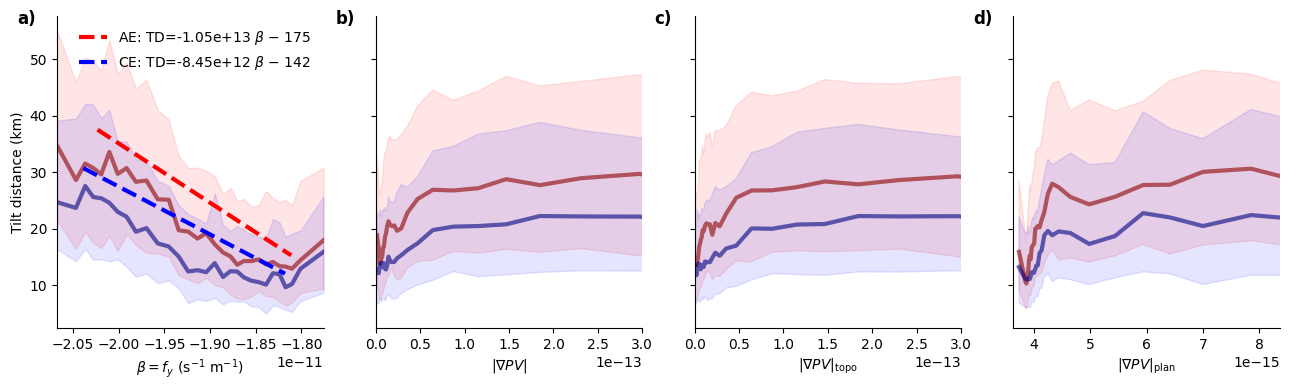

In [9]:
fig, axs = plt.subplots(1, 4, figsize=(13,4), sharey=True)
axs = axs.flatten()

ax = axs[0]
panel(
    df_eddies,
    'beta',
    r'$\beta=f_y$ (s$^{-1}$ m$^{-1}$)',
    r'$\beta$',
    ax=ax,
    xlim_flag=True,
    scatter=False,
    linfit=True,
    # xlim=(0,100)
    # xp=xp,
)
ax.set_ylabel('Tilt distance (km)')


ax = axs[1]
panel(
    df_eddies,
    'PV_grad_mag',
    r'$|\nabla PV|$',
    'x',
    ax=ax,
    xlim_flag=False,
    scatter=False,
    linfit=False,
    # xp=(0,90),
    xlim=(0, 3e-13)
)

ax = axs[2]
panel(
    df_eddies,
    'PV_grad_topo_mag',
    r'$|\nabla PV|_\text{topo}$',
    'x',
    ax=ax,
    xlim_flag=False,
    scatter=False,
    linfit=False,
    # xp=(0,90),
    xlim=(0, 3e-13)
)

ax = axs[3]
panel(
    df_eddies,
    'PV_grad_plan_mag',
    r'$|\nabla PV|_\text{plan}$',
    'x',
    ax=ax,
    xlim_flag=False,
    scatter=False,
    linfit=False,
    xp=(0,90)
    # xlim=(-5e-14, 5e-14)
)

tags = ['a)', 'b)', 'c)', 'd)']
for k, ax in enumerate(axs):
    ax.text(-0.15, 1.02, tags[k], transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left')

plt.tight_layout()


Angle difference between tilt direction and PV gradient

In [10]:
def angle_diff_180(a, b):
    """
    Absolute angular difference between two bearings in degrees.
    Returns values in [0, 180].
    """
    return np.abs((a - b + 180) % 360 - 180)


df_eddies['dtheta_PV_grad'] = angle_diff_180(
    df_eddies['TiltDir'],
    df_eddies['PV_grad_theta']
)

df_eddies['dtheta_PV_grad_topo'] = angle_diff_180(
    df_eddies['TiltDir'],
    df_eddies['PV_grad_topo_theta']
)

df_eddies['dtheta_PV_grad_plan'] = angle_diff_180(
    df_eddies['TiltDir'],
    df_eddies['PV_grad_plan_theta']
)


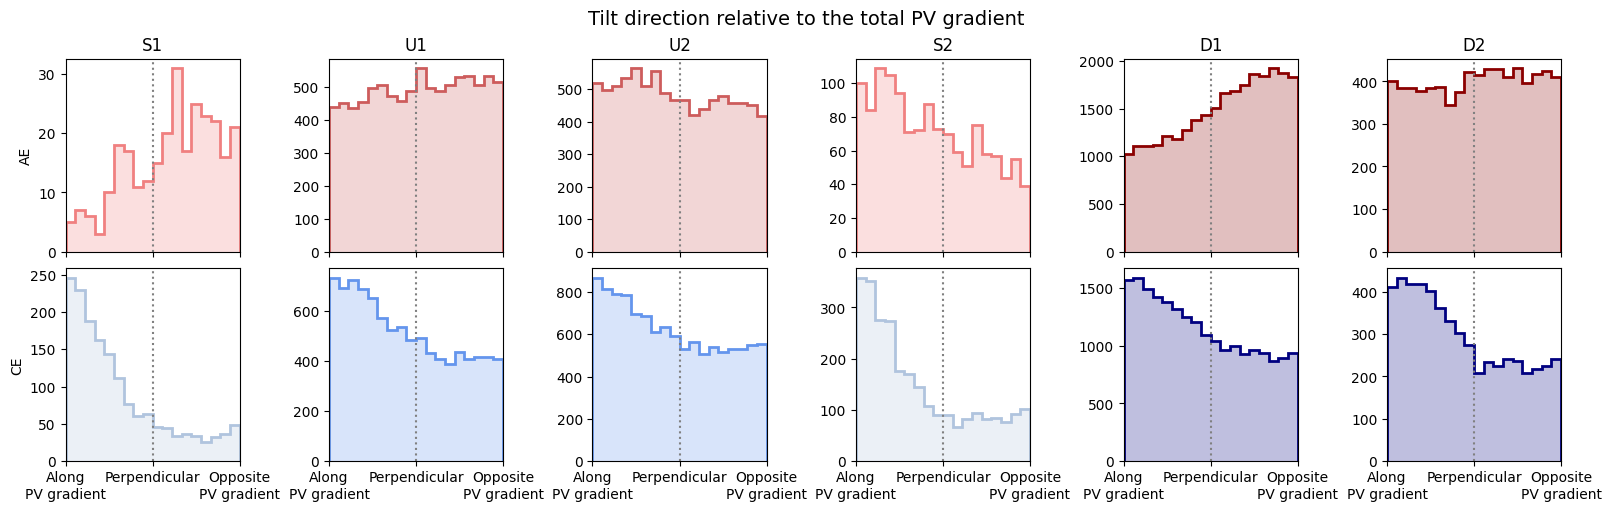

In [27]:
bins = np.arange(0, 181, 10)

fig, axs = plt.subplots(
    2, 6,
    figsize=(16, 5),
    sharex=True,
    sharey=False,
    constrained_layout=True
)

regions = ['S1', 'U1', 'U2', 'S2', 'D1', 'D2']

ae_colors = {
    'S': 'lightcoral',
    'U': 'indianred',
    'D': 'darkred'
}

ce_colors = {
    'S': 'lightsteelblue',
    'U': 'cornflowerblue',
    'D': 'navy'
}

for c, region in enumerate(regions):

    group = region[0]   # 'S', 'U', or 'D'

    ae_color = ae_colors[group]
    ce_color = ce_colors[group]

    # ---------------- AE ----------------
    ax = axs[0, c]

    vals = df_eddies.loc[
        (df_eddies.Cyc == 'AE') &
        (df_eddies.Region == region),
        'dtheta_PV_grad'
    ].dropna()

    ax.hist(
        vals,
        bins=bins,
        histtype='stepfilled',
        alpha=0.25,
        color=ae_color
    )

    ax.hist(
        vals,
        bins=bins,
        histtype='step',
        linewidth=2,
        color=ae_color
    )

    ax.axvline(90, color='grey', ls=':')
    ax.set_title(region)

    if c == 0:
        ax.set_ylabel('AE')

    # ---------------- CE ----------------
    ax = axs[1, c]

    vals = df_eddies.loc[
        (df_eddies.Cyc == 'CE') &
        (df_eddies.Region == region),
        'dtheta_PV_grad'
    ].dropna()

    ax.hist(
        vals,
        bins=bins,
        histtype='stepfilled',
        alpha=0.25,
        color=ce_color
    )

    ax.hist(
        vals,
        bins=bins,
        histtype='step',
        linewidth=2,
        color=ce_color
    )

    ax.axvline(90, color='grey', ls=':')

    if c == 0:
        ax.set_ylabel('CE')

for ax in axs[1]:
    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels([
        'Along\nPV gradient',
        'Perpendicular',
        'Opposite\nPV gradient'
    ])

for ax in axs.ravel():
    ax.set_xlim(0, 180)

fig.suptitle('Tilt direction relative to the total PV gradient', fontsize=14)

plt.show()


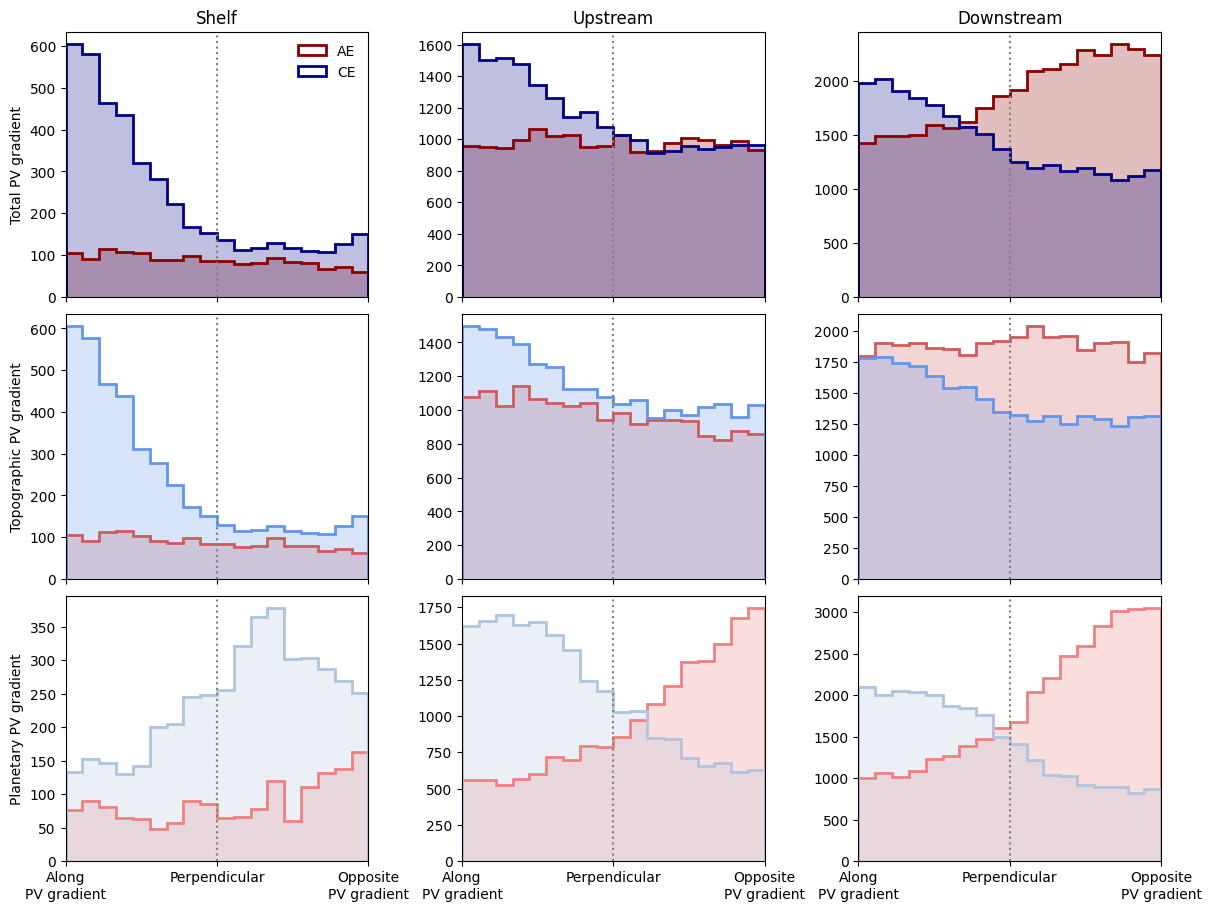

In [13]:
bins = np.arange(0, 181, 10)

fig, axs = plt.subplots(
    3, 3,
    figsize=(12, 9),
    sharex=True,
    constrained_layout=True
)

regions = [
    ['S1', 'S2'],
    ['U1', 'U2'],
    ['D1', 'D2']
]

titles = ['Shelf', 'Upstream', 'Downstream']

theta_cols = [
    'dtheta_PV_grad',
    'dtheta_PV_grad_topo',
    'dtheta_PV_grad_plan'
]

row_labels = [
    'Total PV gradient',
    'Topographic PV gradient',
    'Planetary PV gradient'
]

ae_colors = np.flip(['lightcoral', 'indianred', 'darkred'])
ce_colors = np.flip(['lightsteelblue', 'cornflowerblue', 'navy'])

for r, theta_col in enumerate(theta_cols):

    for c, regs in enumerate(regions):

        ax = axs[r, c]

        for cyc in ['AE', 'CE']:

            df = df_eddies[
                (df_eddies.Cyc == cyc) &
                (df_eddies.Region.isin(regs))
            ]

            vals = df[theta_col].dropna()

            color = ae_colors[r] if cyc == 'AE' else ce_colors[r]

            ax.hist(
                vals,
                bins=bins,
                histtype='stepfilled',
                alpha=0.25,
                color=color
            )

            ax.hist(
                vals,
                bins=bins,
                histtype='step',
                linewidth=2,
                color=color,
                label=cyc if (r == 0 and c == 0) else None
            )

        ax.axvline(90, color='grey', ls=':')

        if r == 0:
            ax.set_title(titles[c])

        if c == 0:
            ax.set_ylabel(row_labels[r])

        ax.set_xlim(0, 180)

for ax in axs[-1]:
    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels([
        'Along\nPV gradient',
        'Perpendicular',
        'Opposite\nPV gradient'
    ])

axs[0,0].legend(frameon=False)

plt.show()


In [14]:
df_eddies['Ro'] = np.abs(df_eddies.w / df_eddies.f)
df_eddies['topo_plan_ratio'] = np.log(df_eddies.PV_grad_topo_mag / df_eddies.PV_grad_plan_mag) # >0 topo dom, <0 plan dom


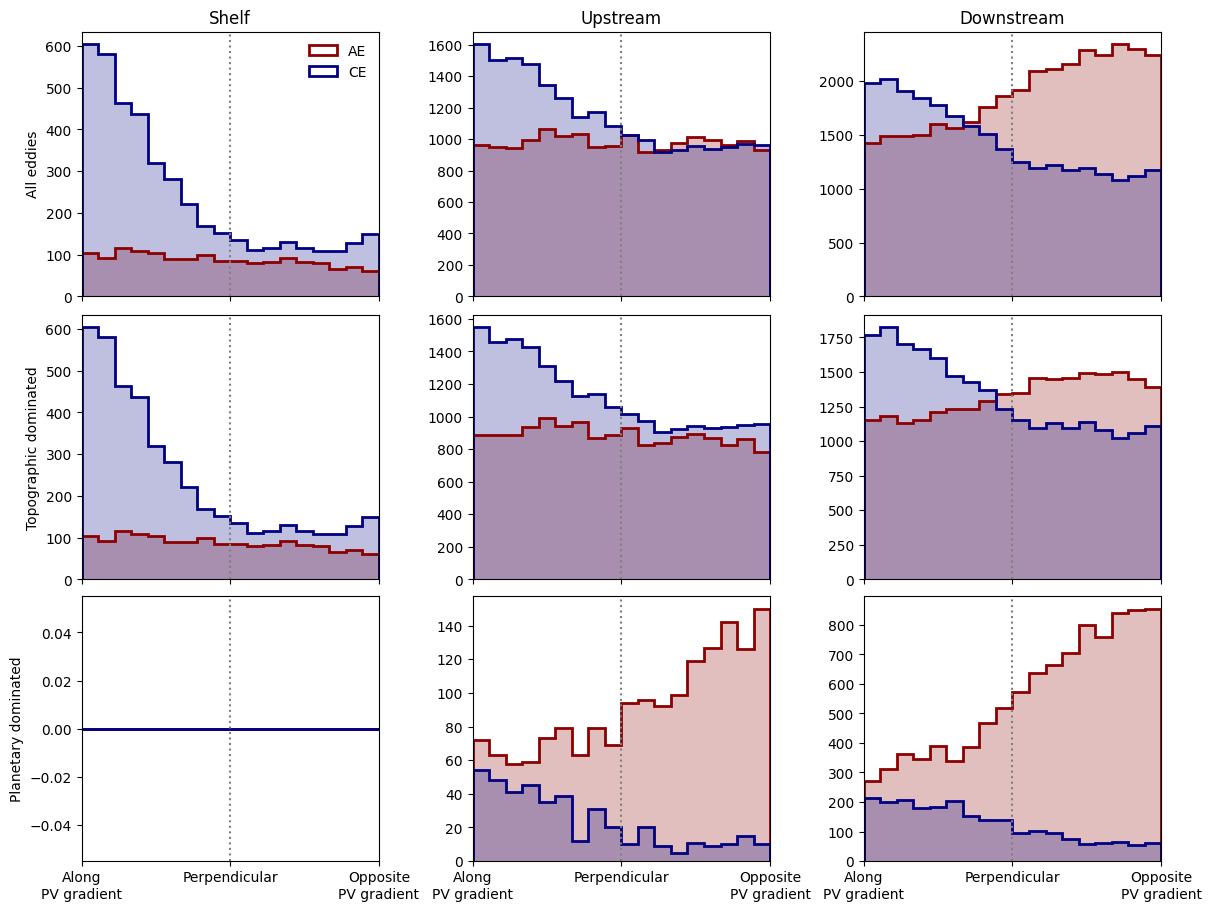

In [15]:
bins = np.arange(0, 181, 10)

fig, axs = plt.subplots(
    3, 3,
    figsize=(12, 9),
    sharex=True,
    # sharey=True,
    constrained_layout=True
)

regions = [
    ['S1', 'S2'],
    ['U1', 'U2'],
    ['D1', 'D2']
]

titles = ['Shelf', 'Upstream', 'Downstream']

row_filters = [
    np.ones(len(df_eddies), dtype=bool),
    df_eddies.topo_plan_ratio > 0,
    df_eddies.topo_plan_ratio < 0,
]

row_labels = [
    'All eddies',
    'Topographic dominated',
    'Planetary dominated'
]

for r, mask in enumerate(row_filters):

    df_row = df_eddies.loc[mask]

    for c, regs in enumerate(regions):

        ax = axs[r, c]

        for cyc, color in zip(
            ['AE', 'CE'],
            ['darkred', 'navy']
        ):

            df = df_row[
                (df_row.Cyc == cyc) &
                (df_row.Region.isin(regs))
            ]

            vals = df['dtheta_PV_grad'].dropna()

            ax.hist(
                vals,
                bins=bins,
                # density=True,
                histtype='stepfilled',
                alpha=0.25,
                color=color
            )

            ax.hist(
                vals,
                bins=bins,
                # density=True,
                histtype='step',
                linewidth=2,
                color=color,
                label=cyc if (r == 0 and c == 0) else None
            )

        ax.axvline(90, color='grey', ls=':')

        if r == 0:
            ax.set_title(titles[c])

        if c == 0:
            ax.set_ylabel(row_labels[r])

        ax.set_xlim(0, 180)

for ax in axs[-1]:
    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels([
        'Along\nPV gradient',
        'Perpendicular',
        'Opposite\nPV gradient'
    ])

axs[0,0].legend(frameon=False)

plt.show()


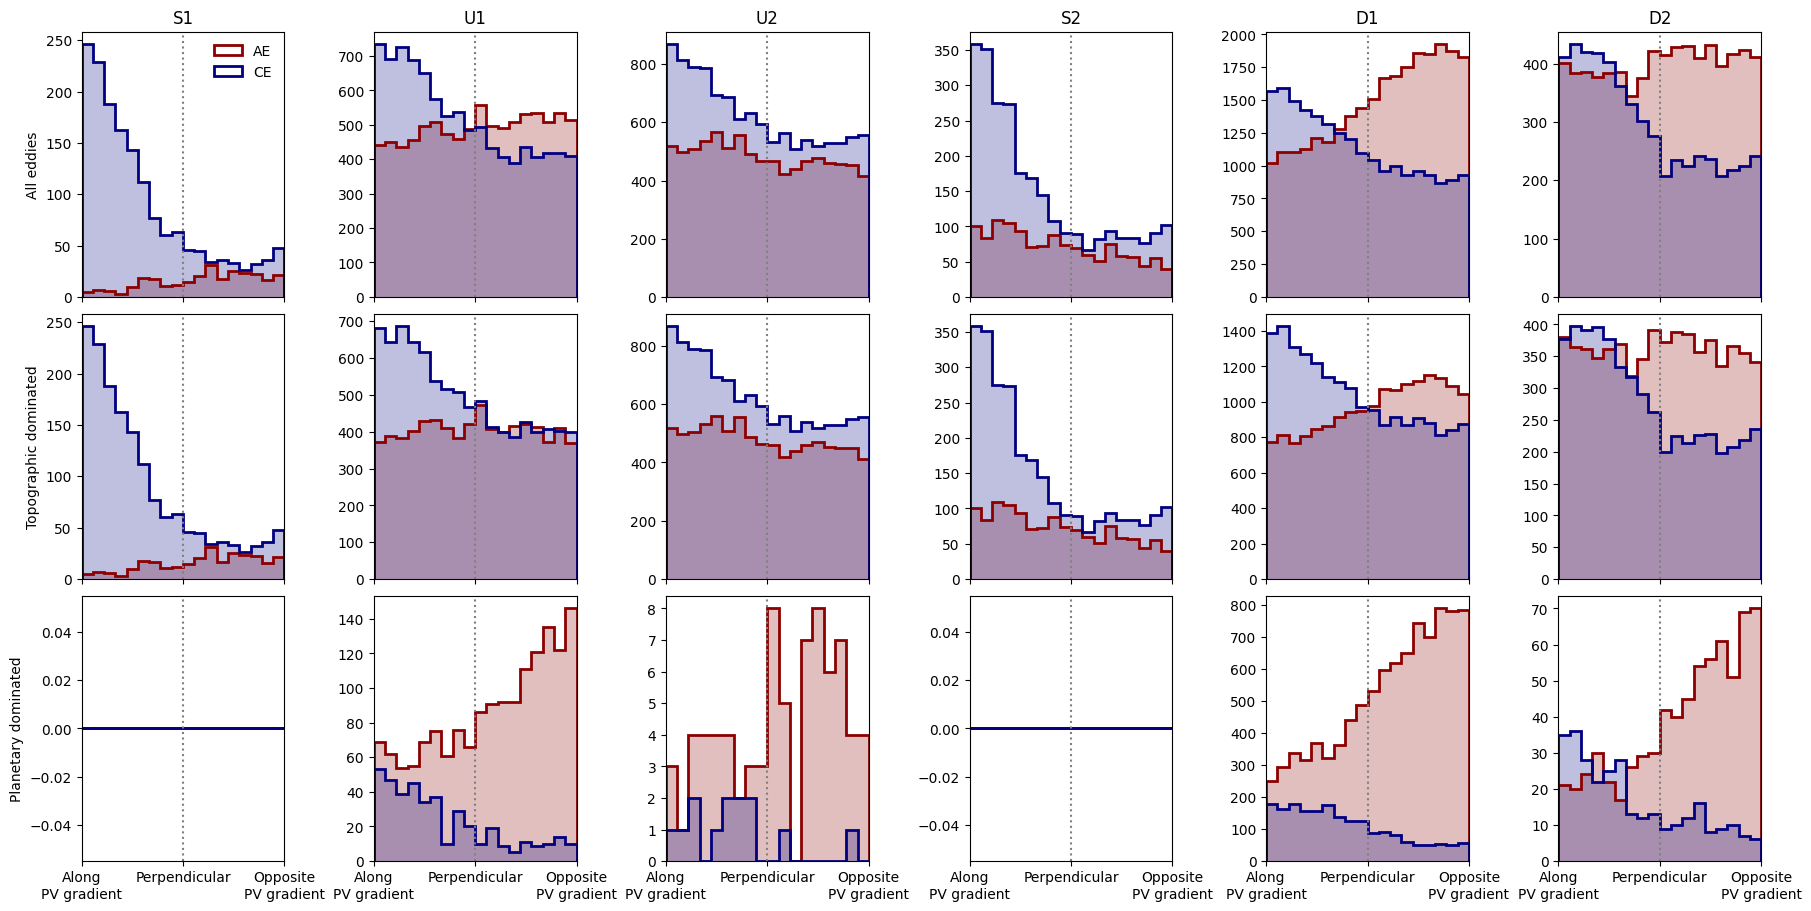

In [16]:
bins = np.arange(0, 181, 10)

region_order = ['S1', 'U1', 'U2', 'S2', 'D1', 'D2']

fig, axs = plt.subplots(
    3, 6,
    figsize=(18, 9),
    sharex=True,
    constrained_layout=True
)

row_filters = [
    np.ones(len(df_eddies), dtype=bool),
    df_eddies.topo_plan_ratio > 0,
    df_eddies.topo_plan_ratio < 0,
]

row_labels = [
    'All eddies',
    'Topographic dominated',
    'Planetary dominated'
]

for r, mask in enumerate(row_filters):

    df_row = df_eddies.loc[mask]

    for c, reg in enumerate(region_order):

        ax = axs[r, c]

        for cyc, color in zip(['AE', 'CE'], ['darkred', 'navy']):

            df = df_row[
                (df_row.Cyc == cyc) &
                (df_row.Region == reg)
            ]

            vals = df['dtheta_PV_grad'].dropna()

            ax.hist(
                vals,
                bins=bins,
                histtype='stepfilled',
                alpha=0.25,
                color=color
            )

            ax.hist(
                vals,
                bins=bins,
                histtype='step',
                linewidth=2,
                color=color,
                label=cyc if (r == 0 and c == 0) else None
            )

        ax.axvline(90, color='grey', ls=':')
        ax.set_xlim(0, 180)

        if r == 0:
            ax.set_title(reg)

        if c == 0:
            ax.set_ylabel(row_labels[r])

for ax in axs[-1]:
    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels([
        'Along\nPV gradient',
        'Perpendicular',
        'Opposite\nPV gradient'
    ])

axs[0, 0].legend(frameon=False)

plt.show()



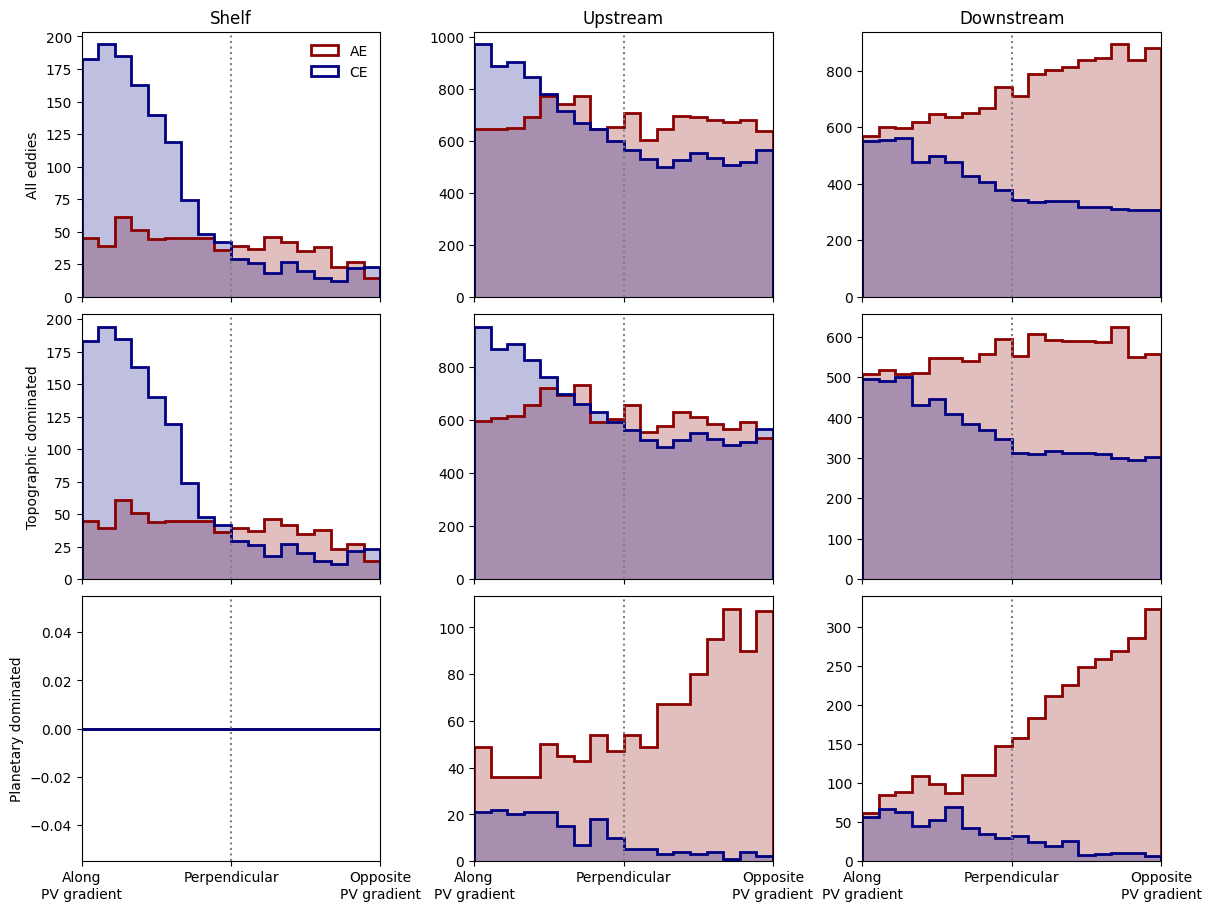

In [17]:
bins = np.arange(0, 181, 10)

fig, axs = plt.subplots(
    3, 3,
    figsize=(12, 9),
    sharex=True,
    # sharey=True,
    constrained_layout=True
)

df_base = df_eddies.copy()
df_base = df_base[df_base.TiltDis>20]
# df_base = df_base[df_base.Ro>.75]

regions = [
    ['S1', 'S2'],
    ['U1', 'U2'],
    ['D1', 'D2']
]

titles = ['Shelf', 'Upstream', 'Downstream']

row_filters = [
    np.ones(len(df_base), dtype=bool),
    df_base.topo_plan_ratio > 0,
    df_base.topo_plan_ratio < 0,
]

row_labels = [
    'All eddies',
    'Topographic dominated',
    'Planetary dominated'
]

for r, mask in enumerate(row_filters):

    df_row = df_base.loc[mask]

    for c, regs in enumerate(regions):

        ax = axs[r, c]

        for cyc, color in zip(
            ['AE', 'CE'],
            ['darkred', 'navy']
        ):

            df = df_row[
                (df_row.Cyc == cyc) &
                (df_row.Region.isin(regs))
            ]

            vals = df['dtheta_PV_grad'].dropna()

            ax.hist(
                vals,
                bins=bins,
                # density=True,
                histtype='stepfilled',
                alpha=0.25,
                color=color
            )

            ax.hist(
                vals,
                bins=bins,
                # density=True,
                histtype='step',
                linewidth=2,
                color=color,
                label=cyc if (r == 0 and c == 0) else None
            )

        ax.axvline(90, color='grey', ls=':')

        if r == 0:
            ax.set_title(titles[c])

        if c == 0:
            ax.set_ylabel(row_labels[r])

        ax.set_xlim(0, 180)

for ax in axs[-1]:
    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels([
        'Along\nPV gradient',
        'Perpendicular',
        'Opposite\nPV gradient'
    ])

axs[0,0].legend(frameon=False)

plt.show()


In [18]:
def rose_plot(mag, theta, frac=5):
    
    # ---------------- six-bin region grid ----------------
    region_mask_grid = (
        (h < 4e3)
        & (X_grid < 400)
        & (lon_rho < 154.85)
        & (mask_rho == 1)
    )
    
    lon_split = 157
    lat_split = -33.5
    
    bin_grid = np.full(X_grid.shape, np.nan)
    
    bin_grid[region_mask_grid & (lat_rho >= lat_split)] = 1
    bin_grid[region_mask_grid & (lat_rho <  lat_split)] = 2
    
    bin_grid[
        (~region_mask_grid)
        & (lon_rho < lon_split)
        & (mask_rho == 1)
        & (lat_rho >= lat_split)
    ] = 3
    
    bin_grid[
        (~region_mask_grid)
        & (lon_rho < lon_split)
        & (mask_rho == 1)
        & (lat_rho < lat_split)
    ] = 4
    
    bin_grid[
        (lon_rho >= lon_split)
        & (mask_rho == 1)
        & (lat_rho >= lat_split)
    ] = 5
    
    bin_grid[
        (lon_rho >= lon_split)
        & (mask_rho == 1)
        & (lat_rho < lat_split)
    ] = 6
    
    
    # ---------------- assign eddy-days to bins ----------------
    df_plot = df_eddies.copy()
    
    tree = cKDTree(
        np.column_stack([X_grid.ravel(), Y_grid.ravel()])
    )
    
    _, idx = tree.query(
        np.column_stack([df_plot.xc, df_plot.yc])
    )
    
    df_plot['bin_id'] = bin_grid.ravel()[idx]
    df_plot = df_plot.dropna(subset=['bin_id'])
    df_plot['bin_id'] = df_plot['bin_id'].astype(int)
    
    
    # ---------------- windrose setup ----------------
    # mag_bins = [0, 10, 20, 30, 40, np.inf]
    mag_bins = [0,
                df_eddies.PV_grad_mag.quantile(0.20),
                # df_eddies.PV_grad_mag.quantile(0.30),
                df_eddies.PV_grad_mag.quantile(0.40),
                # df_eddies.PV_grad_mag.quantile(0.50),
                df_eddies.PV_grad_mag.quantile(0.60),
                df_eddies.PV_grad_mag.quantile(0.80),
                np.inf]
    
    colors_cmps = [
        plt.cm.Oranges(np.linspace(0, 1, len(mag_bins) - 1)),
        plt.cm.Purples(np.linspace(0, 1, len(mag_bins) - 1)),
    ]
    
    cell_w = (X_grid.max() - X_grid.min()) / 3
    cell_h = (Y_grid.max() - Y_grid.min()) / 4
    
    from matplotlib.colors import BoundaryNorm
    
    cmap_bins = plt.cm.gist_ncar
    levels_bins = np.arange(0.5, 7.5, 1)
    norm_bins = BoundaryNorm(levels_bins, cmap_bins.N)
    
    def get_bin_color(b, alpha=0.25):
        color = list(cmap_bins(norm_bins(b)))
        color[-1] = alpha
        return color
    
    
    def choose_local_dir_bins(
        directions_deg,
        min_bins=8,
        max_bins=36,
        min_avg_per_sector=8
    ):
        candidates = np.array([4, 8, 12, 16, 20, 24, 28, 32, 36])
        candidates = candidates[
            (candidates >= min_bins)
            & (candidates <= max_bins)
        ]
    
        d = np.asarray(directions_deg, float)
        d = d[np.isfinite(d)]
        N = len(d)
    
        if N == 0:
            k = 8
        else:
            k0 = int(np.ceil(2 * N ** (1 / 3)))
            k = candidates[np.argmin(np.abs(candidates - k0))]
    
            while k > candidates.min() and (N / k) < min_avg_per_sector:
                k = candidates[candidates < k].max()
    
        dir_bins = np.linspace(0, 360, k + 1)
        dir_shift = 180 / k
    
        return dir_bins, dir_shift
    
    
    def windrose_counts(directions_deg, magnitudes, *, mag_bins):
        d = np.asarray(directions_deg, float)
        m = np.asarray(magnitudes, float)
    
        ok = np.isfinite(d) & np.isfinite(m)
        d = d[ok]
        m = m[ok]
    
        if d.size == 0:
            return None, None, None, None
    
        dir_bins, dir_shift = choose_local_dir_bins(d)
    
        k = len(dir_bins) - 1
        binw_deg = 360 / k
        angles = np.deg2rad(np.arange(k) * binw_deg)
        width = np.deg2rad(binw_deg)
    
        d = np.mod(d + dir_shift, 360)
    
        di = np.digitize(d, dir_bins, right=False) - 1
        mi = np.digitize(m, mag_bins, right=False) - 1
    
        c = np.zeros((len(mag_bins) - 1, k), float)
    
        ok = (
            (di >= 0) & (di < k)
            & (mi >= 0) & (mi < len(mag_bins) - 1)
        )
    
        for d_i, m_i in zip(di[ok], mi[ok]):
            c[m_i, d_i] += 1
    
        return c, angles, width, k
    
    
    def add_windrose(
        ax, x0, y0, data, colors, rmax,
        *, frac=1.6, tick_flag=False, title=''
    ):
        c, angles, width, k = data
    
        if c is None:
            return None
    
        s = frac * min(cell_w, cell_h)
    
        iax = ax.inset_axes(
            [x0 - s / 2, y0 - s / 2, s, s],
            transform=ax.transData,
            projection='polar'
        )
    
        bottom = np.zeros(k)
    
        for i in range(len(mag_bins) - 1):
            hi = r'$\infty$' if np.isinf(mag_bins[i + 1]) else f'{mag_bins[i + 1]:g}'
            label = f'{mag_bins[i]:g}–{hi}'
    
            iax.bar(
                angles,
                c[i],
                width=width,
                bottom=bottom,
                color=colors[i],
                edgecolor=(0, 0, 0, 0.1),
                label=label
            )
    
            bottom += c[i]
    
        iax.set_rlim(0, rmax)
        iax.set_theta_zero_location('N')
        iax.set_theta_direction(-1)
        iax.set_xticks([])
        iax.set_yticks([])
        iax.set_frame_on(False)
    
        if tick_flag:
            iax.legend(
                title=title,
                loc='center left',
                bbox_to_anchor=(1.1, 0.5),
                frameon=True,
                fontsize=9,
                title_fontsize=9
            )
    
        return iax
    
    
    def plot_standalone_windrose(
        ax, data, colors, b,
        title='', tick_flag=False, rmax=None
    ):
        c, angles, width, k = data
    
        if c is None:
            ax.set_axis_off()
            return
    
        ax.set_facecolor(get_bin_color(b, alpha=0.25))
    
        bottom = np.zeros(k)
    
        scale = 1e14
    
        for i in range(len(mag_bins) - 1):
    
            lo = mag_bins[i] * scale
    
            if np.isinf(mag_bins[i + 1]):
                hi = np.inf
                label = f'[{lo:.1f}, ∞)'
            else:
                hi = mag_bins[i + 1] * scale
                label = f'[{lo:.1f}, {hi:.1f})'
    
            ax.bar(
                angles,
                c[i],
                width=width,
                bottom=bottom,
                color=colors[i],
                edgecolor=(0, 0, 0, 0.1),
                label=label
            )
    
            bottom += c[i]
    
        if rmax is not None:
            ax.set_rlim(0, rmax)
    
        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)
    
        cardinal_angles = np.deg2rad([340, 70, 160, 250])
        ax.set_xticks(cardinal_angles)
        ax.set_xticklabels(['N', 'E', 'S', 'W'], fontsize=9)
    
        ax.set_title(title, fontsize=11)
    
        if tick_flag:
            leg = ax.legend(
                title=f'{title[:2]}\nPV gradient\n($\\times10^{-14}$)',
                loc='center left',
                bbox_to_anchor=(1.02, 1.75),
                frameon=True,
                fontsize=8,
                title_fontsize=9,
                borderaxespad=0.5,
                handlelength=1.4,
                handletextpad=0.5,
                labelspacing=0.3
            )
    
            leg._legend_box.align = "left"
    
    
    # ---------------- bin centres ----------------
    bin_centers = {}
    
    for b in range(1, 7):
        yy, xx = np.where(bin_grid == b)
    
        bin_centers[b] = (
            np.nanmean(X_grid[yy, xx]),
            np.nanmean(Y_grid[yy, xx])
        )
    
    
    # ---------------- counts ----------------
    counts = {}
    
    for cyc in ['AE', 'CE']:
        for b in range(1, 7):
    
            sub = df_plot[
                (df_plot.Cyc == cyc)
                & (df_plot.bin_id == b)
            ]
    
            # d = (sub.PV_grad_theta.to_numpy() - 20.0) % 360.0
            # m = sub.PV_grad_mag.to_numpy()
    
            d = (sub[theta].to_numpy() - 20.0) % 360.0
            m = sub[mag].to_numpy()
            
            counts[(cyc, b)] = windrose_counts(
                d,
                m,
                mag_bins=mag_bins
            )
    
    
    # map windroses share scale for regions 3–6 only
    rmax_map = 0
    
    for cyc in ['AE', 'CE']:
        for b in [3, 4, 5, 6]:
    
            c = counts[(cyc, b)][0]
    
            if c is not None:
                rmax_map = max(rmax_map, np.max(c.sum(axis=0)))
    
    rmax_map = 1 if rmax_map == 0 else rmax_map
    
    
    # ---------------- plotting ----------------
    fig = plt.figure(figsize=(21, 8), constrained_layout=True)
    
    gs = fig.add_gridspec(
        1, 4,
        width_ratios=[1.2, 2.6, 1.2, 2.6]
    )
    
    gs_AE_small = gs[0, 0].subgridspec(2, 1)
    gs_CE_small = gs[0, 2].subgridspec(2, 1)
    
    small_axes = {
        ('AE', 1): fig.add_subplot(gs_AE_small[0, 0], projection='polar'),
        ('AE', 2): fig.add_subplot(gs_AE_small[1, 0], projection='polar'),
        ('CE', 1): fig.add_subplot(gs_CE_small[0, 0], projection='polar'),
        ('CE', 2): fig.add_subplot(gs_CE_small[1, 0], projection='polar'),
    }
    
    axs = {
        'AE': fig.add_subplot(gs[0, 1]),
        'CE': fig.add_subplot(gs[0, 3])
    }
    
    for p, cyc in enumerate(['AE', 'CE']):
    
        for b in [1, 2]:
    
            plot_standalone_windrose(
                small_axes[(cyc, b)],
                counts[(cyc, b)],
                colors_cmps[p],
                b,
                title=f'{cyc}, S{b}',
                tick_flag=True if b == 2 else False, #False
                rmax=None
            )
    
    
    for p, cyc in enumerate(['AE', 'CE']):
    
        ax = axs[cyc]
    
        ax.contourf(
            X_grid,
            Y_grid,
            np.where(mask_rho == 0, 1, np.nan),
            levels=[0.5, 1.5],
            colors=['k'],
            alpha=0.5
        )
    
        ax.contourf(
            X_grid,
            Y_grid,
            bin_grid,
            levels=levels_bins,
            cmap=cmap_bins,
            norm=norm_bins,
            alpha=0.25
        )
    
        c1 = ax.contour(
            X_grid,
            Y_grid,
            lat_rho,
            levels=levels_lat,
            colors='k',
            linewidths=0.5
        )
    
        ax.clabel(
            c1,
            fmt=lambda v: f'{np.abs(v):.0f}°S',
            inline=True,
            colors='k'
        )
    
        c2 = ax.contour(
            X_grid,
            Y_grid,
            lon_rho,
            levels=levels_lon,
            colors='k',
            linewidths=0.5
        )
    
        ax.clabel(
            c2,
            fmt=lambda v: f'{v:.0f}°E',
            inline=True,
            colors='k'
        )
    
        ax.contour(
            X_grid,
            Y_grid,
            h,
            levels=[4000],
            colors='k',
            linewidths=1
        )
    
        ax.contour(
            X_grid,
            Y_grid,
            region_mask_grid.astype(float),
            levels=[0.5],
            colors='magenta',
            linewidths=2
        )
    
        ax.contour(
            X_grid,
            Y_grid,
            lon_rho,
            levels=[lon_split],
            colors='magenta',
            linewidths=2,
            linestyles='-'
        )
    
        ax.contour(
            X_grid,
            Y_grid,
            np.where(mask_rho == 1, lat_rho, np.nan),
            levels=[lat_split],
            colors='magenta',
            linewidths=2,
            linestyles='-'
        )
    
        for b in [3, 4, 5, 6]:
    
            x0, y0 = bin_centers[b]
    
            add_windrose(
                ax,
                x0,
                y0,
                counts[(cyc, b)],
                colors_cmps[p],
                rmax_map,
                frac=frac,
                title=f'{cyc}-days:\ntilt dist. (km)'
            )
    
        ax.text(220, 1300, 'S1',
                ha='center', va='center',
                fontsize=12, fontweight='bold')
    
        ax.text(120, 50, 'S2',
                ha='center', va='center',
                fontsize=12, fontweight='bold')
    
        ax.text(400, 1450, 'U1',
                ha='center', va='center',
                fontsize=12, fontweight='bold')
    
        ax.text(800, 1450, 'U2',
                ha='center', va='center',
                fontsize=12, fontweight='bold')
    
        ax.text(620, 750, 'D1',
                ha='center', va='center',
                fontsize=12, fontweight='bold')
    
        ax.text(850, 750, 'D2',
                ha='center', va='center',
                fontsize=12, fontweight='bold')
    
        ax.set_aspect('equal')
        ax.set_xlim(X_grid.min(), X_grid.max())
        ax.set_ylim(Y_grid.min(), Y_grid.max())
    
        ax.set_xlabel('x (km)')
        ax.set_ylabel('y (km)')
    
    
    axs['AE'].text(
        -0.08, 1.02, 'c)',
        transform=axs['AE'].transAxes,
        fontsize=12,
        fontweight='bold',
        va='top',
        ha='left'
    )
    
    axs['CE'].text(
        -0.08, 1.02, 'f)',
        transform=axs['CE'].transAxes,
        fontsize=12,
        fontweight='bold',
        va='top',
        ha='left'
    )
    
    small_axes[('AE', 1)].text(
        -0.15, 1.02, 'a)',
        transform=small_axes[('AE', 1)].transAxes,
        fontsize=12,
        fontweight='bold',
        va='top',
        ha='left'
    )
    
    small_axes[('AE', 2)].text(
        -0.15, 1.02, 'b)',
        transform=small_axes[('AE', 2)].transAxes,
        fontsize=12,
        fontweight='bold',
        va='top',
        ha='left'
    )
    
    small_axes[('CE', 1)].text(
        -0.15, 1.02, 'd)',
        transform=small_axes[('CE', 1)].transAxes,
        fontsize=12,
        fontweight='bold',
        va='top',
        ha='left'
    )
    
    small_axes[('CE', 2)].text(
        -0.15, 1.02, 'e)',
        transform=small_axes[('CE', 2)].transAxes,
        fontsize=12,
        fontweight='bold',
        va='top',
        ha='left'
    )
    
    plt.show()


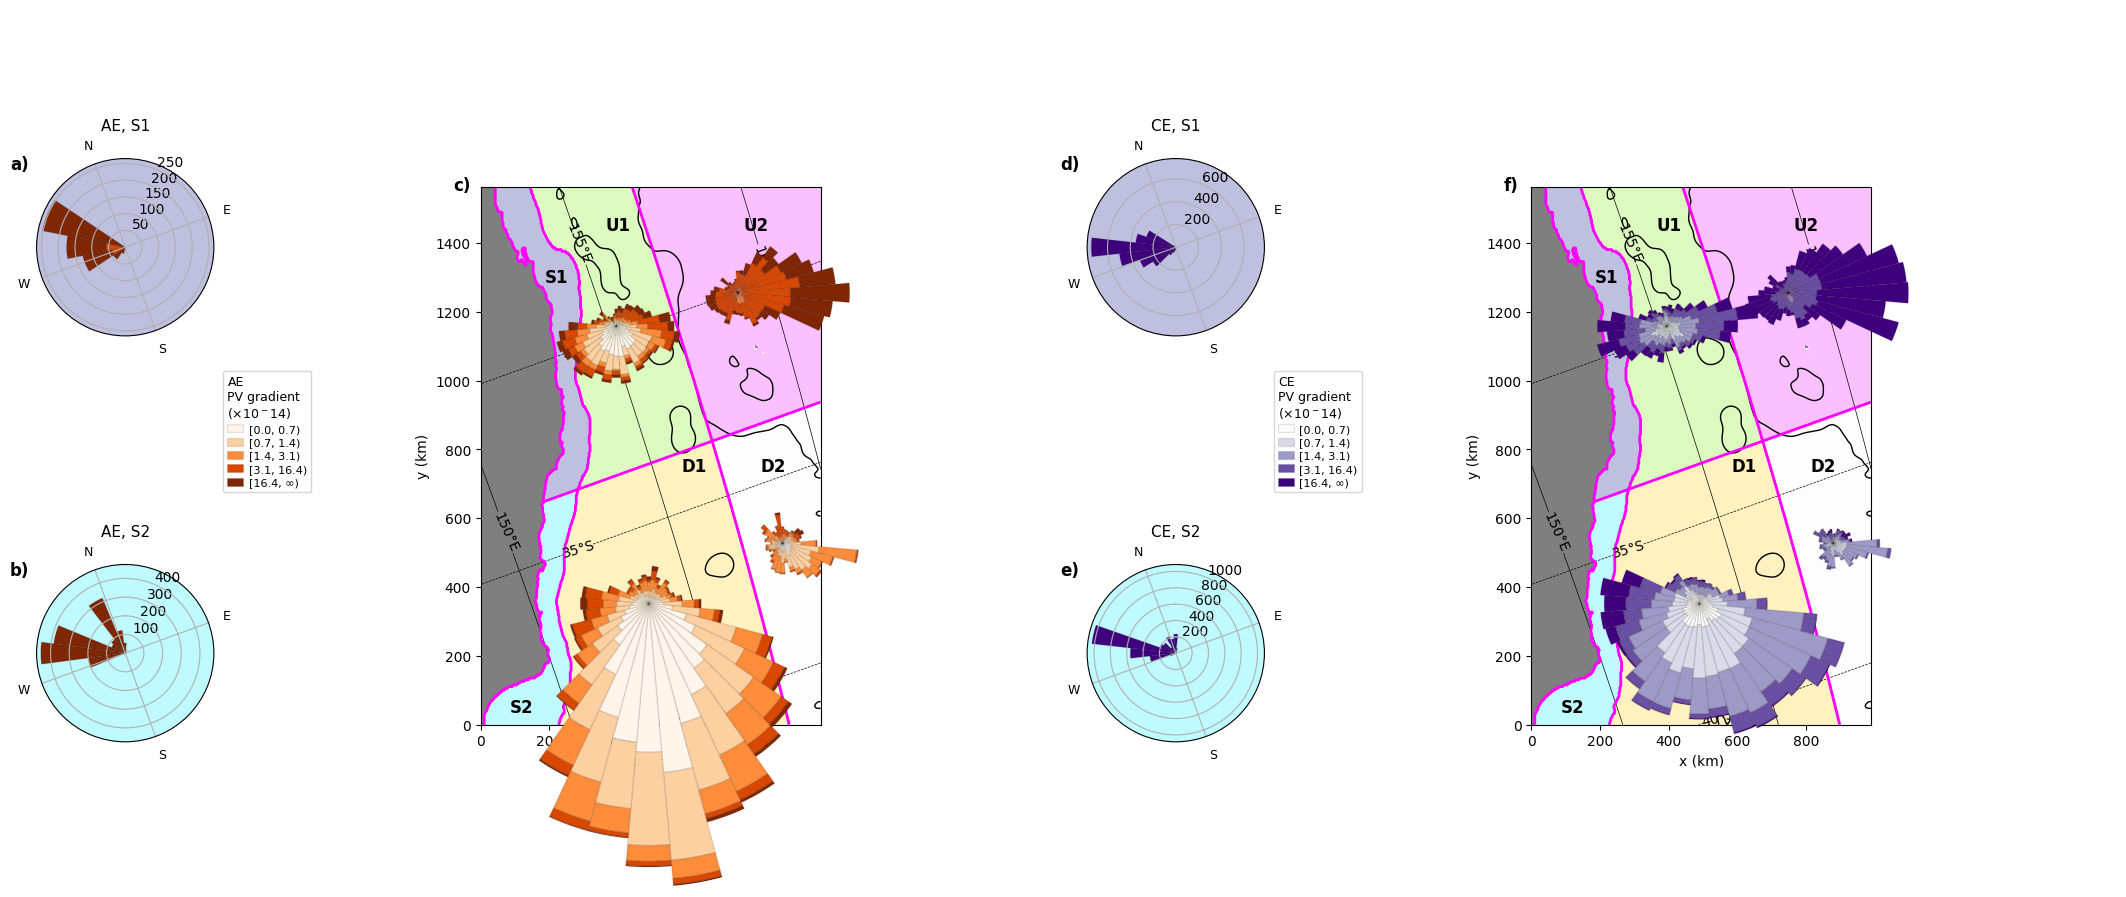

In [19]:
rose_plot(mag='PV_grad_mag', theta='PV_grad_theta')

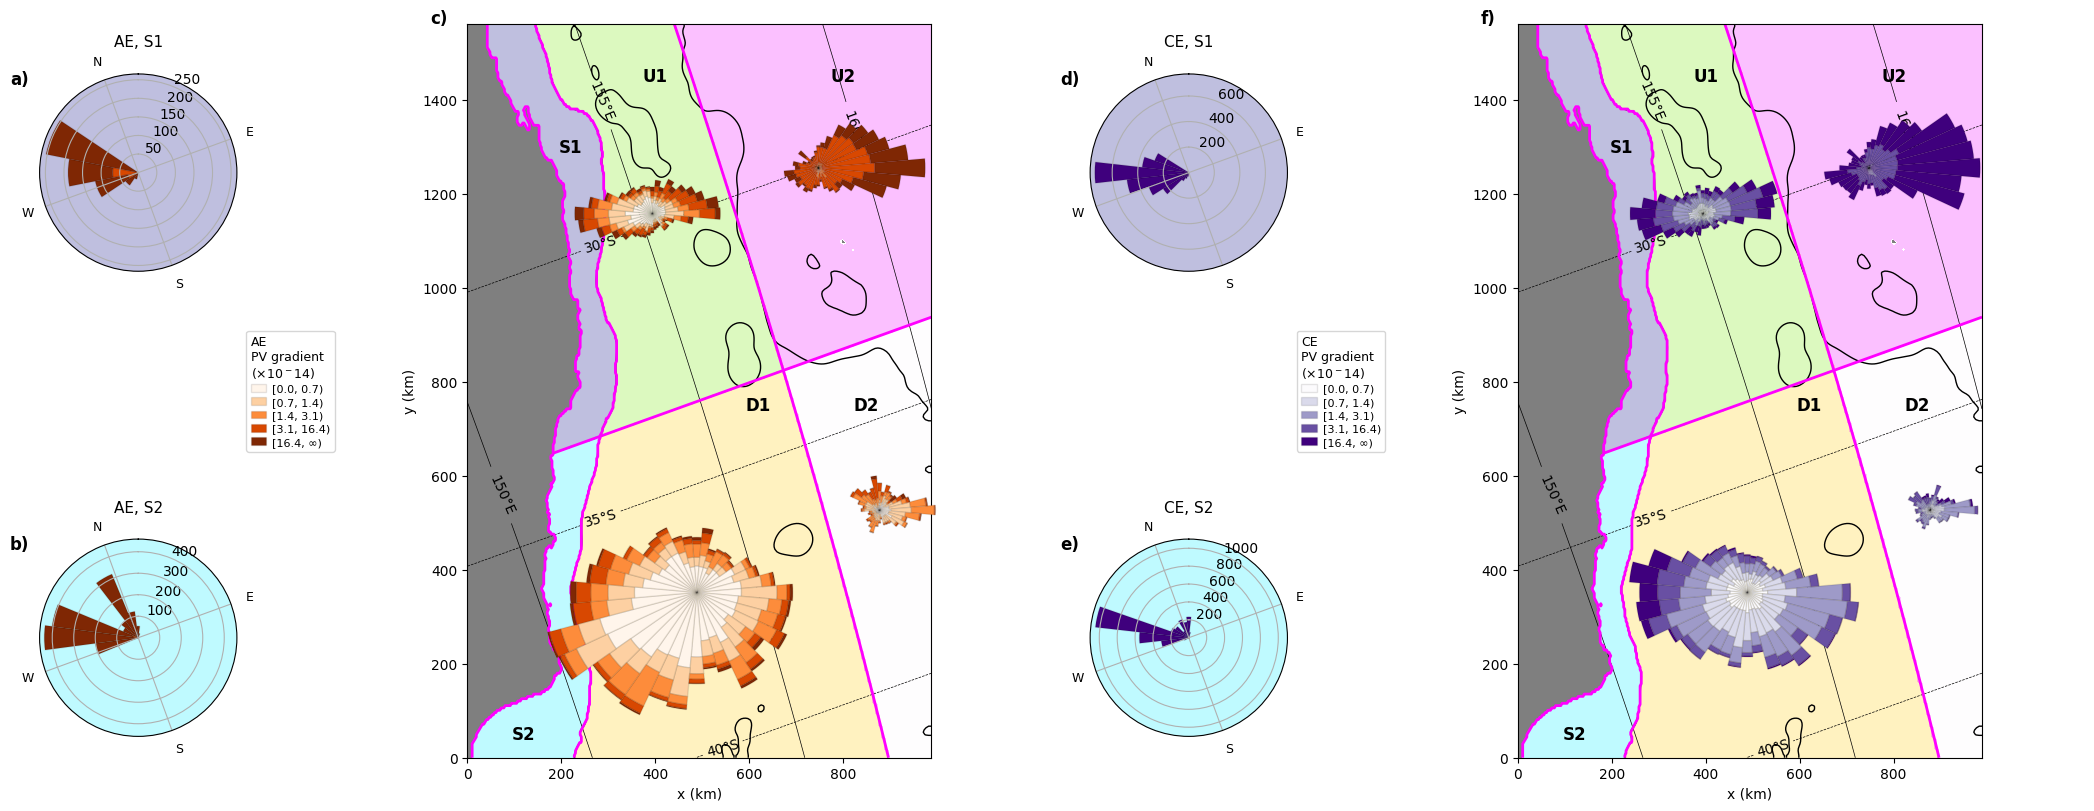

In [20]:
rose_plot(mag='PV_grad_topo_mag', theta='PV_grad_topo_theta', frac=2)

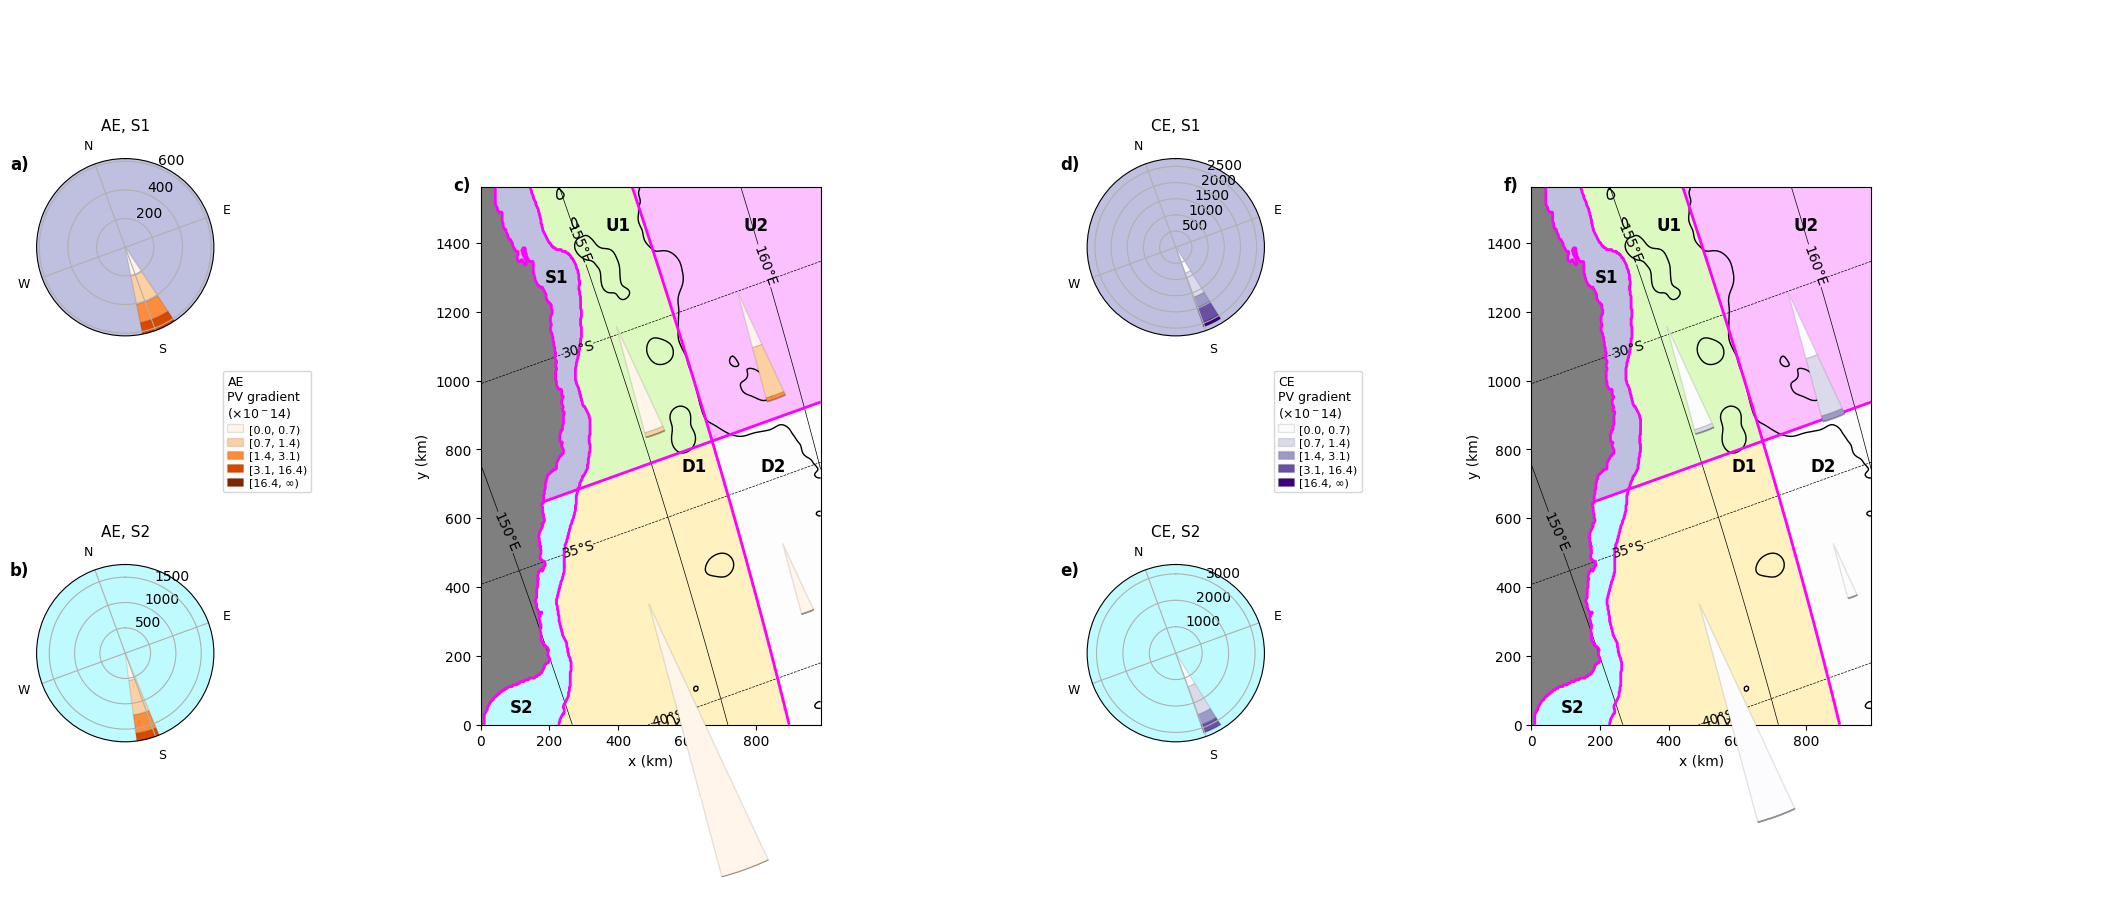

In [21]:
rose_plot(mag='PV_grad_plan_mag', theta='PV_grad_plan_theta')

<Axes: >

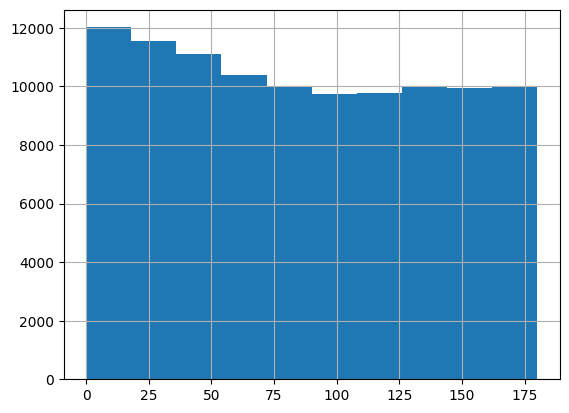

In [22]:
df_eddies['dtheta_PV_grad'].hist()

(0.0, 50.0)

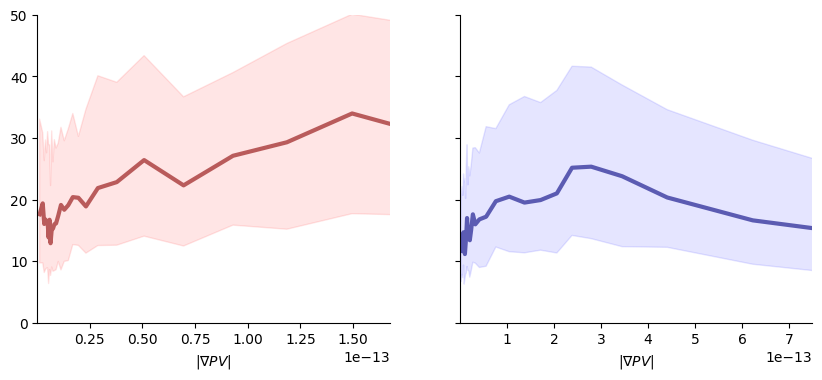

In [23]:
df = df_eddies.copy()
buff = 10
df = df[(df.dtheta_PV_grad<buff)|(df.dtheta_PV_grad>(180-buff))]
fig, axs = plt.subplots(1,2, figsize=(10,4), sharey=True)
for k, cyc in enumerate(['AE', 'CE']):
    ax = axs[k]
    df_cyc = df[df.Cyc==cyc].copy()
    panel(
        df_cyc,
        'PV_grad_mag',
        r'$|\nabla PV|$',
        'x',
        ax=ax,
        xlim_flag=False,
        scatter=False,
        linfit=False,
        xp=(0,90),
        # xlim=(0, 3e-13)
    )
ax.set_ylim(0,50)
    

(0.0, 50.0)

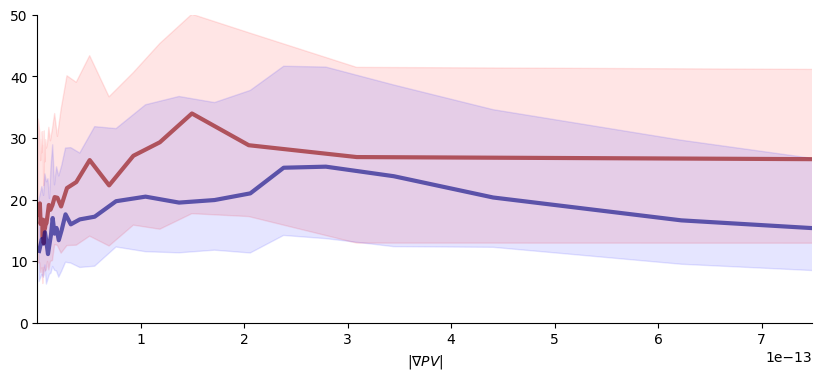

In [24]:
df = df_eddies.copy()
buff = 10
df = df[(df.dtheta_PV_grad<buff)|(df.dtheta_PV_grad>(180-buff))]
fig, ax = plt.subplots(figsize=(10,4), sharey=True)
for k, cyc in enumerate(['AE', 'CE']):
    df_cyc = df[df.Cyc==cyc].copy()
    panel(
        df_cyc,
        'PV_grad_mag',
        r'$|\nabla PV|$',
        'x',
        ax=ax,
        xlim_flag=False,
        scatter=False,
        linfit=False,
        xp=(0,90),
        # xlim=(0, 3e-13)
    )
ax.set_ylim(0,50)
